In [ ]:
import pandas as pd
from matplotlib import figure
from numpy.ma.core import anomalies
from torch.nn.functional import threshold

google = pd.read_csv('../input/GOOGL_2006-01-01_to_2018-01-01.csv', sep=',', na_values=[''], quotechar='"',parse_dates=['Date'], index_col=['Date'])
google.head()
google.info()

In [ ]:
google.isna().sum()

In [ ]:
google.index.is_monotonic_increasing

In [ ]:
google.index.has_duplicates

In [ ]:
google = google[~google.index.duplicated(keep="first")]

In [ ]:
google = google.sort_index()

In [ ]:
import pandas as pd
humidity = pd.read_csv('../input/humidity.csv', sep=',', na_values=[''], quotechar='"',parse_dates=['datetime'], index_col=['datetime'])
humidity.head()
humidity.info()

In [ ]:
city = humidity["Kansas City"]

In [ ]:
city.isna().sum()

In [ ]:
city[city.isna()].head()

In [ ]:
compare = pd.DataFrame({
    "original": city,
    "ffill": city.ffill(),
    "bfill": city.bfill(),
    "interpolate": city.interpolate(method="time")
})

compare.head(20)

In [ ]:
import matplotlib.pyplot as plt

compare["original"].iloc[:200].plot(figsize=(12, 4), label="original")
compare["ffill"].iloc[:200].plot(label="ffill", alpha=0.7)
compare["interpolate"].iloc[:200].plot(label="interpolate", alpha=0.7)

plt.legend()
plt.title("Missing Value Handling")
plt.show()

In [ ]:
dr1 = pd.date_range("1/1/2018","1/1/2019",freq="ME")
dr1

In [ ]:
humidity["Vancouver"].asfreq('ME').plot(legend=True)
shifted = humidity["Vancouver"].asfreq('ME').shift(12).plot(legend=True)
shifted.legend(['Vancouver','Vancouver_lagged'])
plt.show()

In [ ]:
humidity["Vancouver"].asfreq('ME')

In [ ]:
import pandas as pd
pressure = pd.read_csv('../input/pressure.csv', sep=',', na_values=[''], quotechar='"',parse_dates=['datetime'], index_col=['datetime'])
pressure.head()

In [ ]:
pressure.isna().sum()

In [ ]:
pressure_01.isna().sum()

In [ ]:
pressure_01 = pressure.iloc[1:]
pressure_01 = pressure.ffill()
pressure_01.tail()

In [ ]:
pressure_02 = pressure_01.resample("3D").mean()
pressure_02.tail()

In [ ]:
pressure_03 = pressure_01.resample("D").ffill()
pressure_03.tail()

In [ ]:
import pandas as pd
microsoft = pd.read_csv('../input/MSFT_2006-01-01_to_2018-01-01.csv', sep=',', na_values=[''], quotechar='"',parse_dates=['Date'], index_col=['Date'])
microsoft.head()

In [ ]:
microsoft["Close"].plot(figsize=(12, 5), label="GOOGL")
google["Close"].plot( label="MSFT")

plt.title("Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()


In [ ]:
google["Daily Return"] = google["Close"].pct_change()
microsoft["Daily Return"] = microsoft["Close"].pct_change()

google[["Close", "Daily Return"]].head()

In [ ]:
google["Daily Return"].plot(figsize=(12, 5), label="GOOGL")
microsoft["Daily Return"].plot( label="MSFT")
plt.legend()
plt.show()

In [ ]:
google["Daily Return"].hist(bins=50, figsize=(8, 4))


In [ ]:
google["Cumulative Return"] = (google["Daily Return"]+1).cumprod()
microsoft["Cumulative Return"] = (microsoft["Daily Return"]+1).cumprod()

In [ ]:
google["Cumulative Return"].plot(figsize=(12, 5), label="GOOGL")
microsoft["Cumulative Return"].plot(label="MSFT")
plt.title("Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.show()

In [ ]:
google["Close_30MA"] = google["Close"].rolling(30).mean()

In [ ]:
google["Close"].plot(figsize=(12, 5), label="Close")
google["Close_30MA"].plot(label="30-day Moving Average")

plt.title("GOOGL Close Price and 30-day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
google["Close_30MA"] = google["Close"].rolling(30).mean()
google["Close_90MA"] = google["Close"].rolling(90).mean()

google["Close"].plot(figsize=(12, 5), label="Close")
google["Close_30MA"].plot(label="30-day MA")
google["Close_90MA"].plot(label="90-day MA")

plt.title("GOOGL Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
google["Rolling_Volatility"] = google["Close"].rolling(30).std()
google["Rolling_Volatility"].plot(figsize=(12, 4), label="30-day Rolling Volatility")

plt.title("GOOGL 30-day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

In [ ]:
google["Return"] = google["Close"].pct_change()
google["Return_MA30"] = google["Return"].rolling(30).mean()
google["Return_STD30"] = google["Return"].rolling(30).std()

google[["Return", "Return_MA30", "Return_STD30"]].plot(figsize=(12, 5))
plt.title("GOOGL Return, Rolling Mean, and Rolling Std")
plt.show()

In [ ]:
google["Return"] = google["Close"].pct_change()
google["Rolling_Volatility"] = google["Return"].rolling(30).std()

google["Rolling_Volatility"].plot(figsize=(12, 4), label="30-day Rolling Volatility")

plt.title("GOOGL 30-day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()

In [ ]:
prices = pd.concat(
    [
        google["Close"].rename("GOOGL"),
        microsoft["Close"].rename("MSFT")
    ],
    axis=1
)
prices

In [ ]:
normalized_prices = prices / prices.iloc[0]
normalized_prices

In [ ]:
daily_returns = prices.pct_change().dropna()
daily_returns.corr()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

vancouver = humidity["Vancouver"].dropna()
vancouver_daily = humidity["Vancouver"].resample("D").mean().dropna()
# 原始序列
vancouver.plot(figsize=(12, 4))
plt.title("Vancouver Humidity")
plt.xlabel("Datetime")
plt.ylabel("Humidity")
plt.show()

# ACF
plot_acf(vancouver, lags=72)
plt.title("ACF of Vancouver Humidity")
plt.show()

# PACF
plot_pacf(vancouver, lags=72, method="ywm")
plt.title("PACF of Vancouver Humidity")
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    vancouver_daily,
    model="additive",
    period=365
)

decomposition.plot()
plt.show()

In [ ]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

In [ ]:
residual_clean= residual.dropna()
threshold = 3*residual_clean.std()
anomalies = residual_clean[abs(residual_clean) > threshold]
anomalies

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(residual_clean.index, residual_clean, label="Residual")
plt.scatter(
    anomalies.index,
    anomalies,
    label="Potential anomalies"
)
plt.axhline(threshold, linestyle="--")
plt.axhline(-threshold, linestyle="--")
plt.legend()
plt.title("Residual-based Anomaly Detection")
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(vancouver_daily, period=365)
result = stl.fit()

result.plot()
plt.show()

In [ ]:
resid = result.resid


In [ ]:
import numpy as np
white_noise = np.random.normal(0, 1, 500)
pd.Series(white_noise).plot(figsize=(12, 4))
plt.title("White Noise")
plt.show()

In [ ]:
random_walk = white_noise.cumsum()
pd.Series(random_walk).plot(figsize=(12, 4))
plt.title("Random Walk")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller as ADF
vancouver_daily_ADF = ADF(vancouver_daily)
vancouver_daily_ADF

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, window=12):
    series = series.dropna()

    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()

    plt.figure(figsize=(12, 5))
    plt.plot(series, label="Original")
    plt.plot(rolling_mean, label="Rolling Mean")
    plt.plot(rolling_std, label="Rolling Std")
    plt.legend()
    plt.title("Rolling Mean and Rolling Std")
    plt.show()

    result = adfuller(series)

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")

    if result[1] < 0.05:
        print("Conclusion: likely stationary")
    else:
        print("Conclusion: likely non-stationary")
check_stationarity(vancouver_daily, window=30)

In [ ]:
import numpy as np

series_log = np.log(vancouver_daily)
plt.plot(series_log)

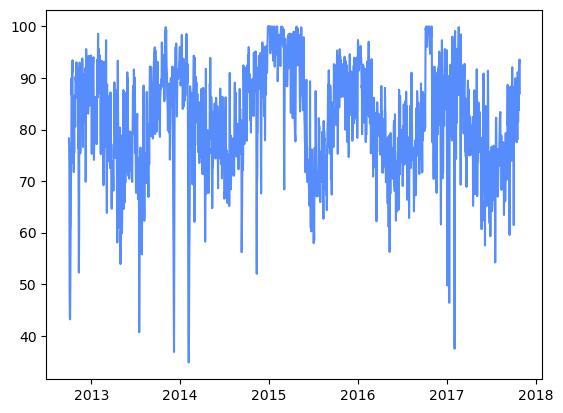

In [92]:
plt.plot(vancouver_daily)

In [93]:
vancouver_daily.tail()

datetime
2017-10-24    84.208333
2017-10-25    92.583333
2017-10-26    93.208333
2017-10-27    93.583333
2017-10-28    87.000000
Name: Vancouver, dtype: float64

In [91]:
vancouver_daily.iloc[-1]

np.float64(87.0)

/opt/anaconda3/envs/torch-env/lib/python3.11/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/opt/anaconda3/envs/torch-env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                           Statespace Model Results                           
Dep. Variable:     ['Close', 'Close']   No. Observations:                 3018
Model:                     VARMA(2,1)   Log Likelihood              -12185.069
                          + intercept   AIC                          24404.138
Date:                Wed, 13 May 2026   BIC                          24506.348
Time:                        12:10:51   HQIC                         24440.892
Sample:                             0                                         
                               - 3018                                         
Covariance Type:                  opg                                         
Ljung-Box (L1) (Q):             0.00, 0.00   Jarque-Bera (JB):   48205.38, 14912.42
Prob(Q):                        0.98, 0.96   Prob(JB):                   0.00, 0.00
Heteroskedasticity (H):         3.31, 1.62   Skew:                      1.15, -0.02
Prob(H) (two-sided):            0.00,

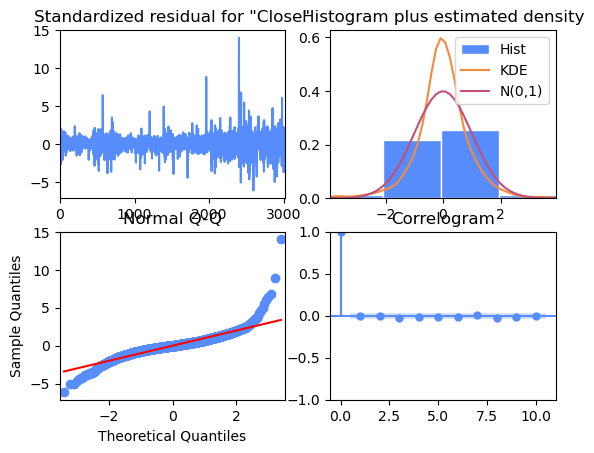

In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm
# Predicting closing price of Google and microsoft
train_sample = pd.concat([google["Close"].diff().iloc[1:],microsoft["Close"].diff().iloc[1:]],axis=1)
model = sm.tsa.VARMAX(train_sample,order=(2,1),trend='c')
result = model.fit(maxiter=1000,disp=False)
print(result.summary())
predicted_result = result.predict(start=0, end=1000)
result.plot_diagnostics()
# calculating error
rmse = mean_squared_error(train_sample.iloc[1:1002].values, predicted_result.values)
print("The root mean squared error is {}.".format(rmse))